In [1]:
#!/bin/python

# Laboratorio 8: Clasificación de Malware con DL


* Marco Ramirez 
* Rebecca Smith

## 📊 Exploración del dataset


<Axes: title={'center': 'Cantidad de muestras por familia'}>

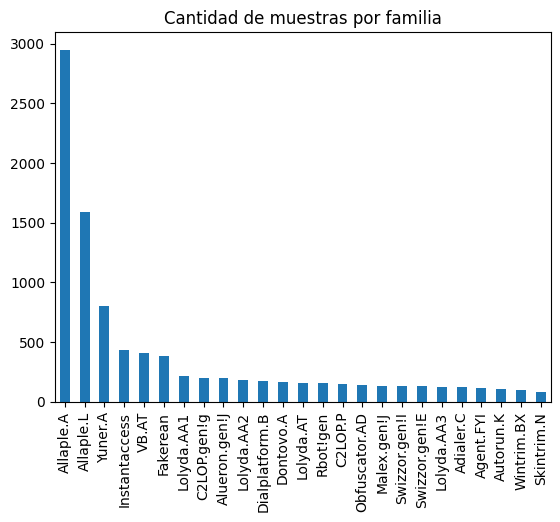

In [2]:
import os

import pandas as pd

base_path = "malimg_paper_dataset_imgs"
familias = [
    folder
    for folder in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, folder))
]
conteo = {
    familia: len(os.listdir(os.path.join(base_path, familia))) for familia in familias
}


pd.Series(conteo).sort_values(ascending=False).plot(
    kind="bar", title="Cantidad de muestras por familia"
)

### 🧹 Filtrado de familias con pocas observaciones

In [3]:
# 📌 Umbral mínimo de imágenes por familia
umbral_minimo = 100

# Filtramos las familias que cumplen con el mínimo
familias_filtradas = [familia for familia, cantidad in conteo.items() if cantidad >= umbral_minimo]

print(f"Se conservarán {len(familias_filtradas)} familias:")
print(familias_filtradas)

Se conservarán 23 familias:
['Swizzor.gen!I', 'Instantaccess', 'Dialplatform.B', 'Autorun.K', 'Dontovo.A', 'C2LOP.gen!g', 'C2LOP.P', 'Lolyda.AA1', 'Lolyda.AT', 'Adialer.C', 'Fakerean', 'Rbot!gen', 'Allaple.A', 'VB.AT', 'Yuner.A', 'Malex.gen!J', 'Swizzor.gen!E', 'Agent.FYI', 'Obfuscator.AD', 'Lolyda.AA2', 'Lolyda.AA3', 'Allaple.L', 'Alueron.gen!J']


Para mejorar el balance del dataset y evitar el sobreajuste, se excluyen las familias con menos de 100 imágenes.

## 🖼️ Visualización de imágenes

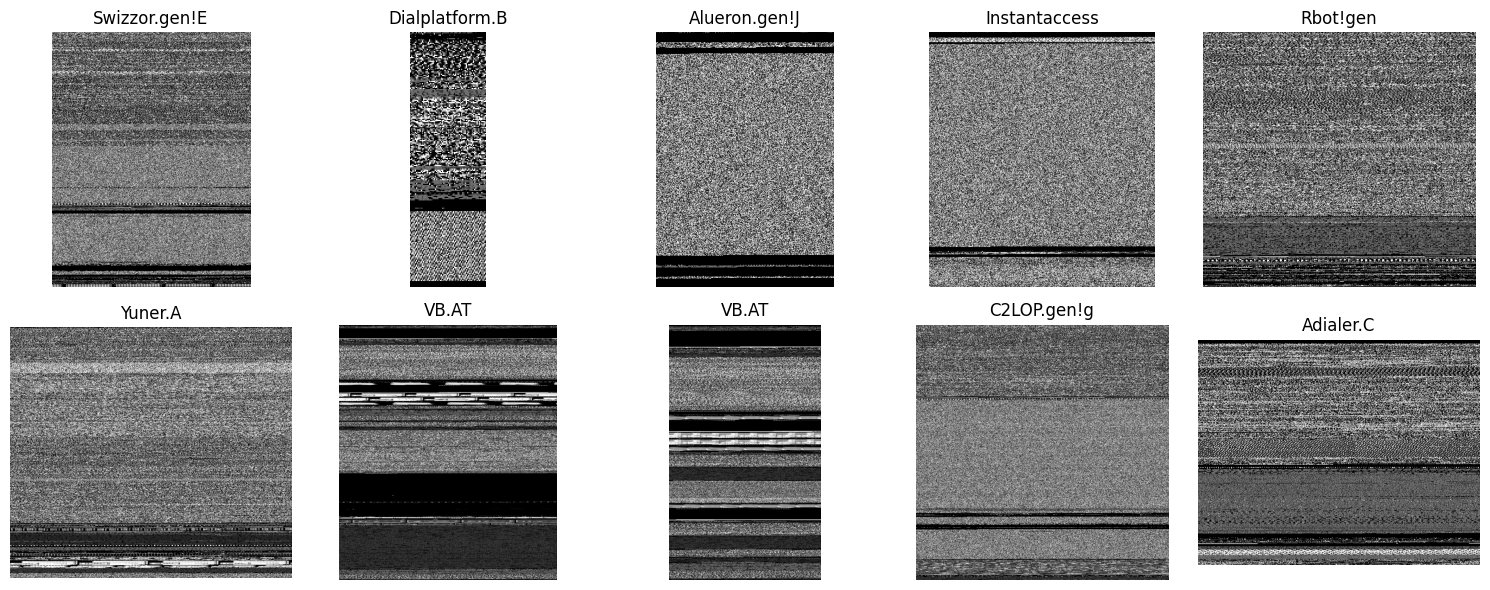

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax in axs.flatten():
    familia = random.choice(familias_filtradas)  # ← aquí el cambio importante
    img_path = os.path.join(
        base_path, familia, random.choice(os.listdir(os.path.join(base_path, familia)))
    )
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap="gray")
    ax.set_title(familia)
    ax.axis("off")
plt.tight_layout()

## 📦 Cargar imágenes (64x64, normalizadas):

In [5]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Dimensiones para redimensionar las imágenes
IMG_SIZE = (64, 64)

X = []
y = []
label_map = {familia: idx for idx, familia in enumerate(familias_filtradas)}

for familia in familias_filtradas:
    carpeta = os.path.join(base_path, familia)
    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        try:
            # Cargar imagen en escala de grises, redimensionar
            imagen = load_img(ruta, color_mode='grayscale', target_size=IMG_SIZE)
            imagen_array = img_to_array(imagen) / 255.0  # Normalizar
            X.append(imagen_array)
            y.append(label_map[familia])
        except Exception as e:
            print(f"Error al procesar {ruta}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (9162, 64, 64, 1)
Shape de y: (9162,)


### División de datos (entrenamiento vs prueba)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6413, 64, 64, 1), Test: (2749, 64, 64, 1)


### Construcción del modelo CNN con Keras

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(familias_filtradas), activation='softmax')  # Clasificación multiclase
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Security_Data_Science/Security_Data_Science/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-01 14:38:46.584641: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-05-01 14:38:46.584687: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-01 14:38:46.584701: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1746131926.584981 15748230 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746131926.585009 15748230 plug

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,543 (6.21 MB)

 Trainable params: 1,627,543 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

### entrenamiento del modelo

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15


2025-05-01 14:39:16.701715: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4300 - loss: 2.0181 - val_accuracy: 0.9032 - val_loss: 0.4187
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7949 - loss: 0.7897 - val_accuracy: 0.9200 - val_loss: 0.2570
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8929 - loss: 0.4383 - val_accuracy: 0.9509 - val_loss: 0.1772
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9078 - loss: 0.3901 - val_accuracy: 0.9542 - val_loss: 0.1723
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9305 - loss: 0.2889 - val_accuracy: 0.9553 - val_loss: 0.1619
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9371 - loss: 0.2370 - val_accuracy: 0.9563 - val_loss: 0.1747
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9540 - loss: 0.1771 - val_accuracy: 0.9593 - val_loss: 0.1283
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9493 - loss: 0.1894 - val_accuracy: 0.961

### Gráficas de entrenamiento

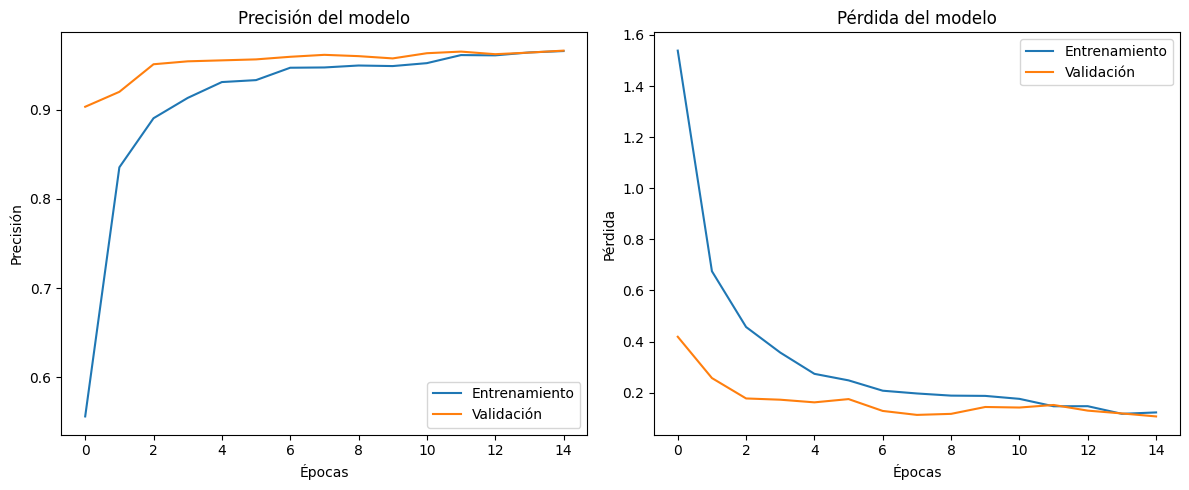

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluación final y métricas

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9674 - loss: 0.1054

🔍 Evaluación en test: accuracy = 0.9662, loss = 0.1068
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.65      0.60        40
           1       1.00      1.00      1.00       129
           2       1.00      1.00      1.00        53
           3       0.00      0.00      0.00        32
           4       1.00      1.00      1.00        49
           5       0.81      0.92      0.86        60
           6       0.86      0.70      0.78        44
           7       0.98      0.98      0.98        64
           8       1.00      0.98      0.99        48
           9       1.00      1.00      1.00        37
          10       0.99      0.99      0.99       114
          11       0.98      0.94      0.96        47
          12       1.00      1.00      1.00       885
          13       1.00      1.00      1.00     

/Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Security_Data_Science/Security_Data_Science/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Security_Data_Science/Security_Data_Science/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Security_Data_Science/Security_Data_Science/.venv/lib/python3.11/site

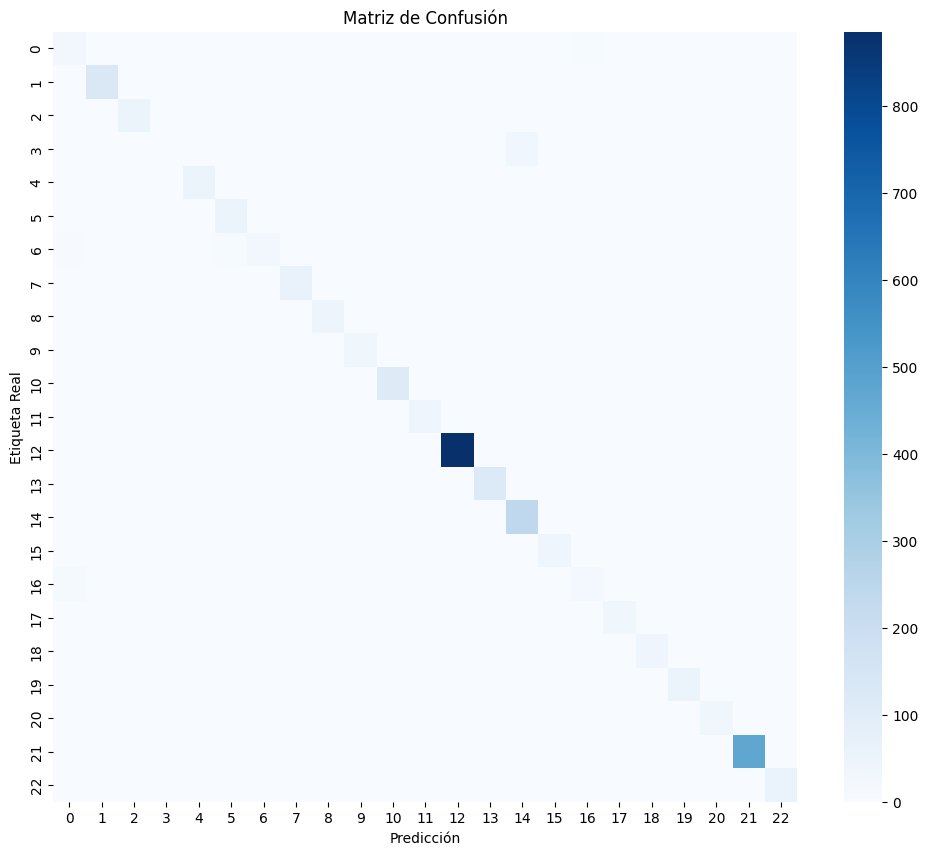

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluación en test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\n🔍 Evaluación en test: accuracy = {test_accuracy:.4f}, loss = {test_loss:.4f}")

# Reporte de clasificación
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, cmap="Blues", fmt='g')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.show()

La matriz de confusión muestra que el modelo logra una clasificación precisa para la mayoría de las familias de malware.  
Las predicciones correctas se alinean fuertemente con la diagonal, lo que indica buen rendimiento general.  
Algunas clases presentan leves confusiones, probablemente debido a similitudes visuales entre ciertas familias.

En general, la red neuronal convolucional demuestra ser efectiva para esta tarea de clasificación.